# Rep. 3. Checkpoint 3. Limitaciones de Black-Scholes y modelos alternativos


In [16]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, kurtosis, skew
import warnings
warnings.filterwarnings('ignore')

In [17]:
# Parametros para heston
S0    = 669.03
v0    = 0.04
mu    = 0.042
kappa = 2.0
theta = 0.04
xi = [0.1 , 0.4, 0.9]
rho   = -0.7
T     = 1.0
N     = 252
M     = 1000

def simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M, seed=42):
    """
    S0    : precio inicial
    v0    : varianza inicial
    mu    : drift
    kappa : velocidad de reversión
    theta : varianza de largo plazo
    xi    : vol of vol
    rho   : correlación precio-volatilidad
    T     : tiempo en años
    N     : número de pasos
    M     : número de simulaciones
    """
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    v  = np.zeros((M, N + 1))
    S[:, 0] = S0
    v[:, 0] = v0

    for t in range(1, N + 1):
        Z1 = np.random.randn(M)
        Z2 = np.random.randn(M)
        Zs = Z1
        Zv = rho * Z1 + np.sqrt(1 - rho**2) * Z2  # correlación

        v_pos = np.maximum(v[:, t-1], 0)           # evita varianza negativa

        v[:, t] = (v_pos
                   + kappa * (theta - v_pos) * dt
                   + xi * np.sqrt(v_pos * dt) * Zv)
        v[:, t] = np.maximum(v[:, t], 0)

        S[:, t] = S[:, t-1] * np.exp(
            (mu - 0.5 * v_pos) * dt
            + np.sqrt(v_pos * dt) * Zs
        )
    return S, v


# Parametros para merton
S0      = 669.03
mu      = 0.042
sigma   = 0.15
lam = [1,4,15]
mu_j    = -0.015    # saltos promedio de -5%
sigma_j = 0.10
T       = 1.0
N       = 252
M       = 1000

def simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M, seed=42):
    """
    lam     : intensidad de saltos (saltos/año)
    mu_j    : media del log-salto
    sigma_j : desviación del log-salto
    """
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    S[:, 0] = S0

    for t in range(1, N + 1):
        # Componente difusiva (GBM)
        Z     = np.random.randn(M)
        gbm   = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

        # Componente de saltos (Poisson)
        n_saltos  = np.random.poisson(lam * dt, M)          # número de saltos en dt
        log_salto = np.array([
            np.sum(np.random.normal(mu_j, sigma_j, n))
            if n > 0 else 0.0
            for n in n_saltos
        ])

        S[:, t] = S[:, t-1] * np.exp(gbm + log_salto)

    return S

### Para Heston: prueba con ξ = 0.1, ξ = 0.4 y ξ = 0.9

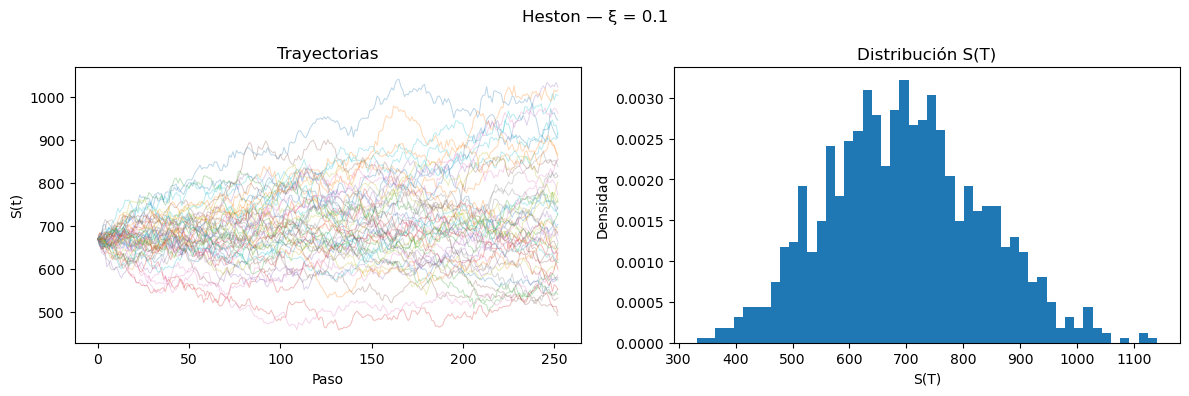

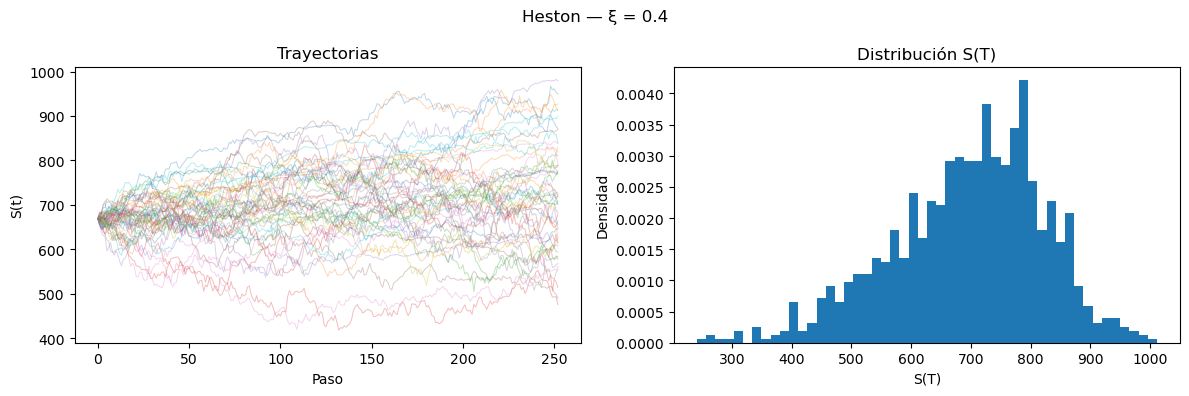

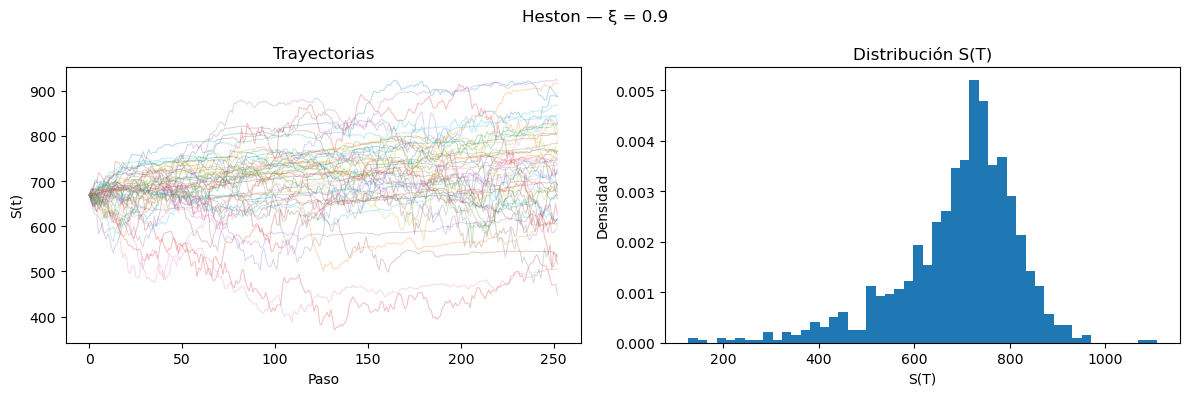

In [18]:
for xi_val in xi:
    S, v = simular_heston(S0, v0, mu, kappa, theta, xi_val, rho, T, N, M)
 
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Heston — ξ = {xi_val}")
 
    axes[0].plot(S[:50].T, alpha=0.3, lw=0.7)
    axes[0].set_title("Trayectorias")
    axes[0].set_xlabel("Paso")
    axes[0].set_ylabel("S(t)")
 
    axes[1].hist(S[:, -1], bins=50, density=True)
    axes[1].set_title("Distribución S(T)")
    axes[1].set_xlabel("S(T)")
    axes[1].set_ylabel("Densidad")
 
    plt.tight_layout()
    plt.show()

### Para Merton: prueba con λ = 1, λ = 4 y λ = 15

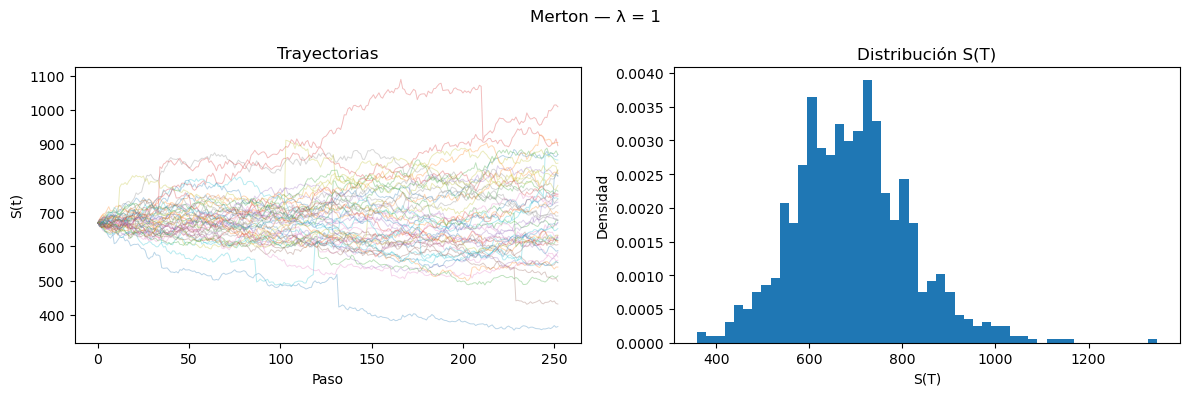

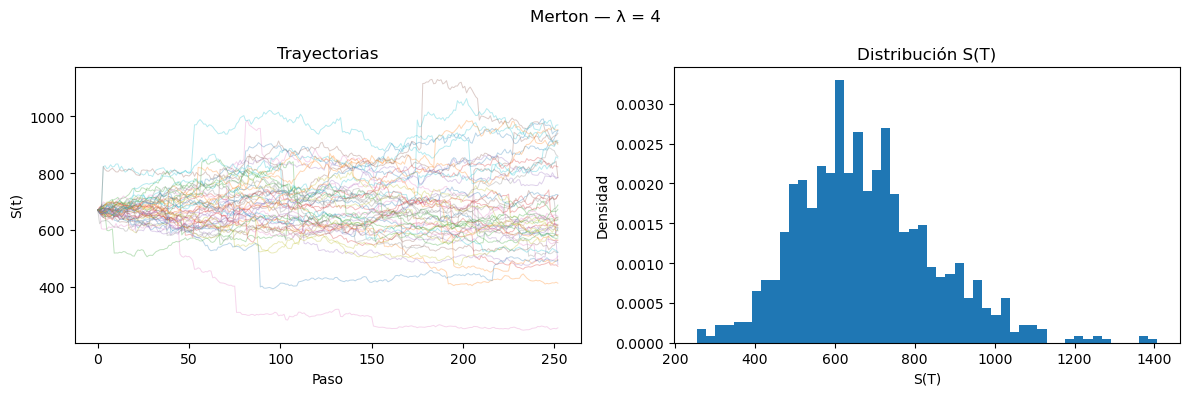

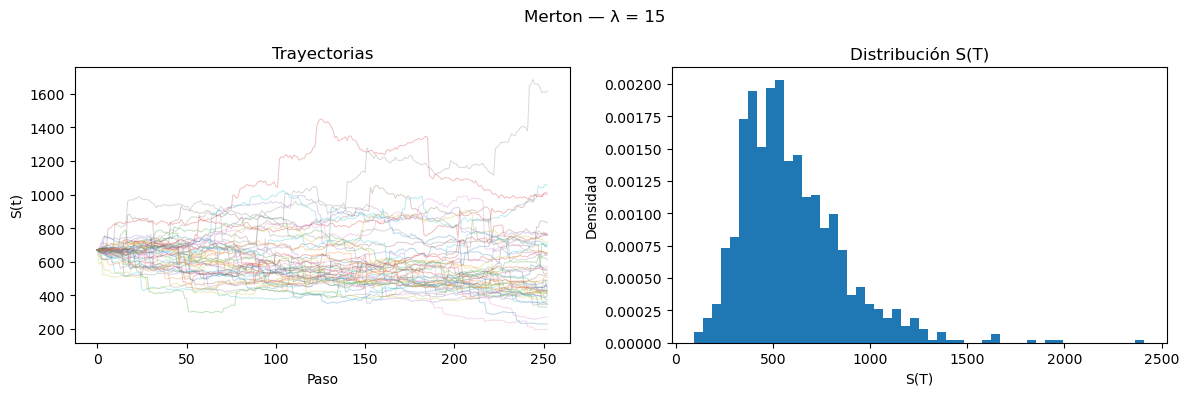

In [19]:
for lam_val in lam:
    S = simular_merton(S0, mu, sigma, lam_val, mu_j, sigma_j, T, N, M)
 
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Merton — λ = {lam_val}")
 
    axes[0].plot(S[:50].T, alpha=0.3, lw=0.7)
    axes[0].set_title("Trayectorias")
    axes[0].set_xlabel("Paso")
    axes[0].set_ylabel("S(t)")
 
    axes[1].hist(S[:, -1], bins=50, density=True)
    axes[1].set_title("Distribución S(T)")
    axes[1].set_xlabel("S(T)")
    axes[1].set_ylabel("Densidad")
 
    plt.tight_layout()
    plt.show()

## Preguntas
Responde dentro del notebook como celdas de texto (Markdown), tal vez necesites investigar para contestar:

- **En la simulación de Heston, ¿qué efecto tiene aumentar ξ (vol of vol) sobre la distribución del precio final? ¿Y sobre el skew?**

     La curtosis parece aumentar mientras la ξ aumenta, esto porque mientras la volatilidad aumenta, se pueden encontrar eventos más extremos. Mientras que el skew parece convertirse en negativo, teniendo una cola muy pesada hacia el lado izquierdo.

- **En la simulación de Merton, cambia λ de 4 a 15. ¿Cómo cambian las trayectorias? ¿Y la distribución final?**

    Las trayectorias parecen concentrarse mayormente en precios más bajos (pérdidas), casi como si tuvieran la tendencia de irse más abajo. La distribución parece cambiar mucho, teniendo una alta concentración en la cola izquierda, con eventos extremos en la cola derecha.

- **Si el mercado tiene fat tails y BS los ignora, ¿en qué dirección estará sesgado el precio BS de un put muy OTM, sobreestimado o subestimado? ¿Por qué?**

    Subestima, un put se beneficia de caidas de precio y black scholes ausume una distribucuon normal, con colas normales. Lo que significa que en caso de fat tails BS predice que la probabilidad real de que el precio caiga por debajo del strike sea muy baja, cuando en realidad(contantando fat tails), seria mucho mayor. Por lo tanto el precio deberia de estar mas arriba de lo que predice BS, en otras palabras en el precio BS de un put muy OTM seria negativo.

- **Merton asume que los saltos son predecibles en frecuencia (λ constante). ¿Qué limitación tiene eso en la práctica?**

    Que el mercado realmente no se comporta de esa manera, existe el volatility clustering, por lo que una lambda constante nunca podrá capturar esos periodos de crisis donde los saltos aumentan de forma drástica.  

- **¿Por qué crees que BS sigue siendo el estándar de cotización a pesar de que Heston y Merton son más precisos?**

    Porque se convirtió en el lenguaje común, el mercado siempre usa la implied volatility en términos de BS, es lo que se usa entre trades para comunicarse. Sin mencionar que es extremadamente fácil y rápido calcularlo en comparación con Heston y Merton, es una simple fórmula analítica que todos usan. 
